## 2.1 理论计算题

### 1. 非线性激活函数的重要性

**代数推导证明：**

已知隐藏层：$\mathbf{h} = \mathbf{W}_1 \mathbf{x} + \mathbf{b}_1$
已知输出层：$\mathbf{o} = \mathbf{W}_2 \mathbf{h} + \mathbf{b}_2$

将 $\mathbf{h}$ 代入 $\mathbf{o}$ 的表达式：
$$
\begin{aligned}
\mathbf{o} &= \mathbf{W}_2 (\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 \\
&= \mathbf{W}_2 \mathbf{W}_1 \mathbf{x} + \mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2
\end{aligned}
$$

令 $\mathbf{W}' = \mathbf{W}_2 \mathbf{W}_1$，$\mathbf{b}' = \mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2$，则：
$$
\mathbf{o} = \mathbf{W}' \mathbf{x} + \mathbf{b}'
$$

**结论：** 该网络等价于一个单层神经网络，其中权重矩阵 $\mathbf{W}' = \mathbf{W}_2 \mathbf{W}_1$，偏置向量 $\mathbf{b}' = \mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2$。

### 2. 激活函数性质分析

**Sigmoid 函数**
- 表达式：$\sigma(x) = \frac{1}{1 + e^{-x}}$
- 导数推导：
  $$
  \sigma'(x) = \frac{e^{-x}}{(1 + e^{-x})^2} = \frac{1}{1 + e^{-x}} \cdot \frac{e^{-x}}{1 + e^{-x}} = \sigma(x)(1 - \sigma(x))
  $$

**tanh 函数**
- 表达式：$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
- 导数推导：
  $$
  \tanh'(x) = \frac{(e^x + e^{-x})^2 - (e^x - e^{-x})^2}{(e^x + e^{-x})^2} = 1 - \tanh^2(x)
  $$

### 2.2 编程题

Epoch [1/10], Loss: 1.4289
Epoch [2/10], Loss: 0.7696
Epoch [3/10], Loss: 0.6430
Epoch [4/10], Loss: 0.5733
Epoch [5/10], Loss: 0.5318
Epoch [6/10], Loss: 0.5050
Epoch [7/10], Loss: 0.4865
Epoch [8/10], Loss: 0.4722
Epoch [9/10], Loss: 0.4601
Epoch [10/10], Loss: 0.4509

Test Accuracy: 82.81%


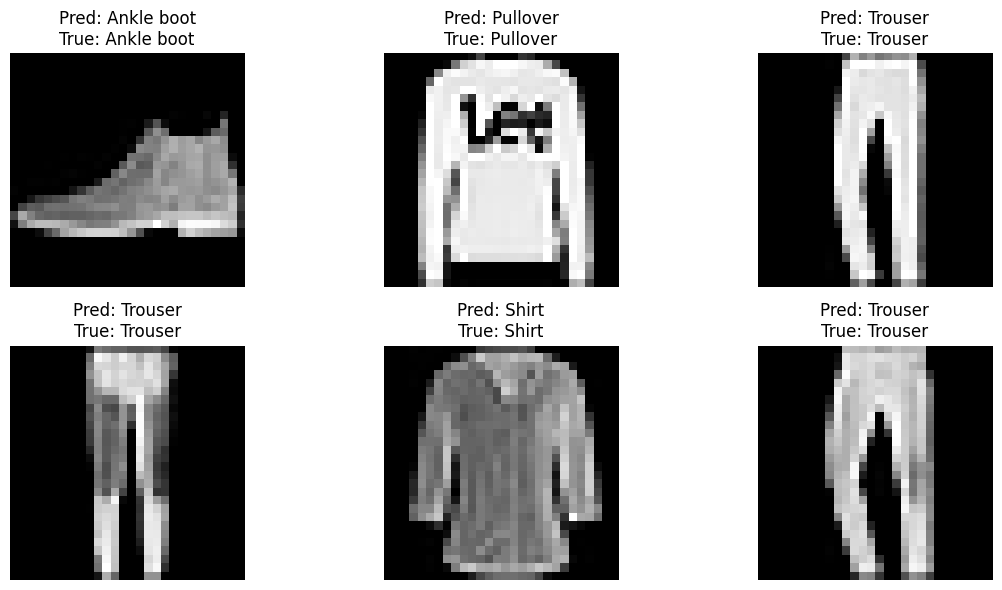

In [8]:

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# =========================================================
# 超参数设置
# =========================================================

input_size = 28 * 28
hidden_size = 256
output_size = 10

learning_rate = 0.01
batch_size = 64
epochs = 10

# =========================================================
# 加载 Fashion-MNIST 数据集
# =========================================================

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# =========================================================
# 手动初始化参数（正态分布）
# =========================================================

torch.manual_seed(42)

W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.randn(hidden_size) * 0.01

W2 = torch.randn(hidden_size, output_size) * 0.01
b2 = torch.randn(output_size) * 0.01

# =========================================================
# ReLU 激活函数
# =========================================================

def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

# =========================================================
# Softmax 函数
# =========================================================

def softmax(x):

    # 防止指数溢出
    x = x - torch.max(x, dim=1, keepdim=True).values

    exp_x = torch.exp(x)

    return exp_x / torch.sum(exp_x, dim=1, keepdim=True)

# =========================================================
# 交叉熵损失函数
# =========================================================

def cross_entropy(y_pred, y_true):

    m = y_true.shape[0]

    epsilon = 1e-8

    correct_probs = y_pred[range(m), y_true]

    loss = -torch.mean(torch.log(correct_probs + epsilon))

    return loss

# =========================================================
# 模型训练
# =========================================================

for epoch in range(epochs):

    total_loss = 0

    for images, labels in train_loader:

        # 展平图片
        X = images.view(-1, 28 * 28)

        # =================================================
        # 前向传播
        # =================================================

        # 隐藏层
        Z1 = torch.matmul(X, W1) + b1

        A1 = relu(Z1)

        # 输出层
        Z2 = torch.matmul(A1, W2) + b2

        Y_hat = softmax(Z2)

        # 计算损失
        loss = cross_entropy(Y_hat, labels)

        total_loss += loss.item()

        # =================================================
        # 反向传播（手动求梯度）
        # =================================================

        m = labels.shape[0]

        # One-hot 编码
        Y = torch.zeros(m, output_size)

        Y[range(m), labels] = 1

        # 输出层梯度
        dZ2 = (Y_hat - Y) / m

        dW2 = torch.matmul(A1.t(), dZ2)

        db2 = torch.sum(dZ2, dim=0)

        # 隐藏层梯度
        dA1 = torch.matmul(dZ2, W2.t())

        dZ1 = dA1 * (Z1 > 0).float()

        dW1 = torch.matmul(X.t(), dZ1)

        db1 = torch.sum(dZ1, dim=0)

        # =================================================
        # Mini-batch SGD 更新参数
        # =================================================

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

# =========================================================
# 测试模型
# =========================================================

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        X = images.view(-1, 28 * 28)

        # 前向传播
        Z1 = torch.matmul(X, W1) + b1

        A1 = relu(Z1)

        Z2 = torch.matmul(A1, W2) + b2

        Y_hat = softmax(Z2)

        predictions = torch.argmax(Y_hat, dim=1)

        total += labels.size(0)

        correct += (predictions == labels).sum().item()

accuracy = 100 * correct / total

print(f"\nTest Accuracy: {accuracy:.2f}%")

# =========================================================
# 可视化预测结果
# =========================================================

classes = [
    'T-shirt',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

images, labels = next(iter(test_loader))

X = images.view(-1, 28 * 28)

# 前向传播
Z1 = torch.matmul(X, W1) + b1

A1 = relu(Z1)

Z2 = torch.matmul(A1, W2) + b2

Y_hat = softmax(Z2)

predictions = torch.argmax(Y_hat, dim=1)

# 绘图
plt.figure(figsize=(12, 6))

for i in range(6):

    plt.subplot(2, 3, i + 1)

    plt.imshow(images[i].squeeze(), cmap='gray')

    plt.title(
        f"Pred: {classes[predictions[i]]}\nTrue: {classes[labels[i]]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()



## 3.1 理论计算题

### 1. 过拟合与欠拟合

训练误差 (Training Error) 与泛化误差 (Generalization Error) 的区别：

- 训练误差：模型在训练数据集上计算得到的误差。它反映了模型对训练数据的拟合程度。
- 泛化误差：模型在测试集（或新的、未见过的数据）上计算得到的误差。它反映了模型在真实应用场景下的预测能力。

模型状态分析：

当一个模型的训练误差极低，但泛化误差很高时，模型处于 过拟合 (Overfitting) 状态。

缓解方法（控制模型复杂度）：

可以通过以下方式控制模型复杂度来缓解过拟合：

1.  降低模型容量：减少模型参数的数量（例如减少隐藏层单元数或网络层数）。
2.  添加正则化项：在损失函数中加入权重衰减（L2 正则化）或 L1 正则化，限制参数的大小。
3.  使用丢弃法 (Dropout)：在训练过程中随机丢弃部分神经元，防止某些特征被过度依赖。
4.  早停 (Early Stopping)：在验证集误差开始上升时停止训练。
5.  增加训练数据量：引入更多样化的数据。

### 2. K 折交叉验证

K 折交叉验证 (K-fold Cross-Validation) 的具体实施算法步骤：

1.  数据划分：将原始训练数据集 $\mathcal{D}$ 随机划分为 $K$ 个大小近似相等的互斥子集，记为 $\mathcal{D}_1, \mathcal{D}_2, \dots, \mathcal{D}_K$。
2.  循环训练与验证：对于 $k = 1, 2, \dots, K$，执行以下操作：
    - 将第 $k$ 个子集 $\mathcal{D}_k$ 保留作为**验证集**。
    - 将剩余的 $K-1$ 个子集 ($\mathcal{D} \setminus \mathcal{D}_k$) 合并作为**训练集**。
    - 在当前训练集上训练模型。
    - 在当前验证集上评估模型，记录验证集误差 $E_k$。
3.  计算平均误差：计算 $K$ 次验证误差的平均值：
    $$ E_{CV} = \frac{1}{K} \sum_{k=1}^{K} E_k $$
4.  确定模型性能：使用 $E_{CV}$ 作为模型性能的估计指标。
5.  最终训练：确定最优模型超参数后，通常在完整的训练集 $\mathcal{D}$ 上重新训练一次模型，以获得最终的模型参数。 

### 3.2 编程题

none | Epoch [1/15] Train Loss: 1.4289 Test Loss: 0.8928
none | Epoch [2/15] Train Loss: 0.7694 Test Loss: 0.7063
none | Epoch [3/15] Train Loss: 0.6430 Test Loss: 0.6216
none | Epoch [4/15] Train Loss: 0.5734 Test Loss: 0.5719
none | Epoch [5/15] Train Loss: 0.5321 Test Loss: 0.5403
none | Epoch [6/15] Train Loss: 0.5051 Test Loss: 0.5266
none | Epoch [7/15] Train Loss: 0.4863 Test Loss: 0.5143
none | Epoch [8/15] Train Loss: 0.4718 Test Loss: 0.5136
none | Epoch [9/15] Train Loss: 0.4608 Test Loss: 0.4834
none | Epoch [10/15] Train Loss: 0.4506 Test Loss: 0.4786
none | Epoch [11/15] Train Loss: 0.4425 Test Loss: 0.4681
none | Epoch [12/15] Train Loss: 0.4351 Test Loss: 0.4617
none | Epoch [13/15] Train Loss: 0.4281 Test Loss: 0.4557
none | Epoch [14/15] Train Loss: 0.4225 Test Loss: 0.4567
none | Epoch [15/15] Train Loss: 0.4168 Test Loss: 0.4499
l2 | Epoch [1/15] Train Loss: 1.4317 Test Loss: 0.8930
l2 | Epoch [2/15] Train Loss: 0.7732 Test Loss: 0.7066
l2 | Epoch [3/15] Train Loss:

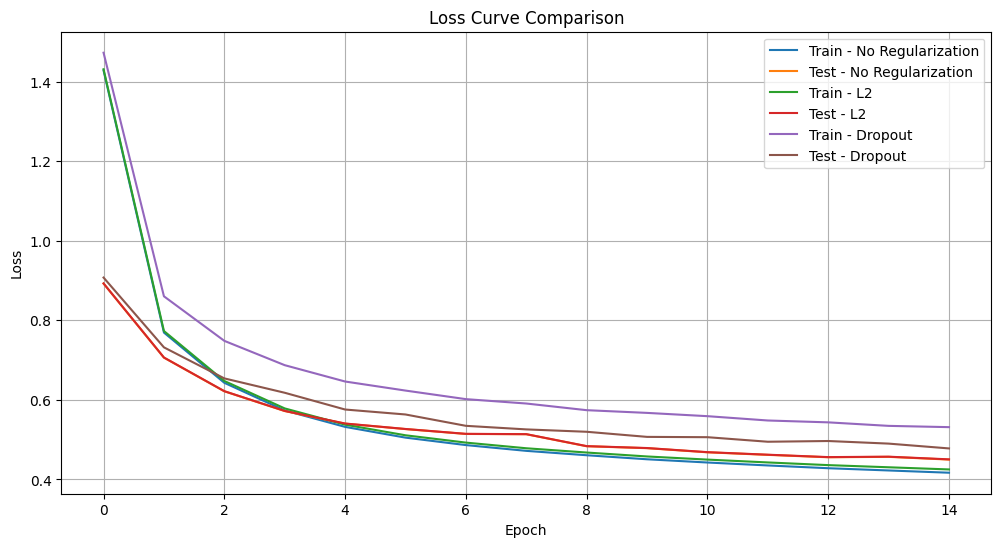

In [9]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# =========================================================
# 超参数
# =========================================================

input_size = 28 * 28
hidden_size = 256
output_size = 10

learning_rate = 0.01
batch_size = 64
epochs = 15

# L2 正则化系数
lambda_l2 = 1e-4

# Dropout 概率
dropout_rate = 0.5

# =========================================================
# 数据集
# =========================================================

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# =========================================================
# 激活函数
# =========================================================

def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

# =========================================================
# Softmax
# =========================================================

def softmax(x):

    x = x - torch.max(x, dim=1, keepdim=True).values

    exp_x = torch.exp(x)

    return exp_x / torch.sum(exp_x, dim=1, keepdim=True)

# =========================================================
# 交叉熵损失
# =========================================================

def cross_entropy(y_pred, y_true):

    m = y_true.shape[0]

    epsilon = 1e-8

    correct_probs = y_pred[range(m), y_true]

    loss = -torch.mean(torch.log(correct_probs + epsilon))

    return loss

# =========================================================
# Dropout 层（手写）
# =========================================================

def dropout_layer(X, dropout, is_training=True):

    # 测试阶段不 Dropout
    if not is_training:
        return X

    # dropout = 0 不处理
    if dropout == 0:
        return X

    # dropout = 1 全部置零
    if dropout == 1:
        return torch.zeros_like(X)

    # 生成 Mask
    mask = (torch.rand(X.shape) > dropout).float()

    # 缩放
    return mask * X / (1.0 - dropout)

# =========================================================
# 初始化参数
# =========================================================

def init_parameters():

    torch.manual_seed(42)

    W1 = torch.randn(input_size, hidden_size) * 0.01
    b1 = torch.randn(hidden_size) * 0.01

    W2 = torch.randn(hidden_size, output_size) * 0.01
    b2 = torch.randn(output_size) * 0.01

    return W1, b1, W2, b2

# =========================================================
# 模型训练函数
# =========================================================

def train_model(mode='none'):

    """
    mode:
        'none'      无正则化
        'l2'        L2正则化
        'dropout'   Dropout
    """

    W1, b1, W2, b2 = init_parameters()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):

        total_train_loss = 0

        # =================================================
        # 训练
        # =================================================

        for images, labels in train_loader:

            X = images.view(-1, 28 * 28)

            # 前向传播
            Z1 = torch.matmul(X, W1) + b1

            A1 = relu(Z1)

            # Dropout
            if mode == 'dropout':
                A1 = dropout_layer(
                    A1,
                    dropout_rate,
                    is_training=True
                )

            Z2 = torch.matmul(A1, W2) + b2

            Y_hat = softmax(Z2)

            # 基础交叉熵
            loss = cross_entropy(Y_hat, labels)

            # L2 正则项
            if mode == 'l2':

                l2_loss = (
                    torch.sum(W1 ** 2)
                    + torch.sum(W2 ** 2)
                )

                loss = loss + lambda_l2 * l2_loss

            total_train_loss += loss.item()

            # =================================================
            # 反向传播
            # =================================================

            m = labels.shape[0]

            Y = torch.zeros(m, output_size)

            Y[range(m), labels] = 1

            # 输出层
            dZ2 = (Y_hat - Y) / m

            dW2 = torch.matmul(A1.t(), dZ2)

            db2 = torch.sum(dZ2, dim=0)

            # 隐藏层
            dA1 = torch.matmul(dZ2, W2.t())

            dZ1 = dA1 * (Z1 > 0).float()

            dW1 = torch.matmul(X.t(), dZ1)

            db1 = torch.sum(dZ1, dim=0)

            # =================================================
            # L2 Weight Decay
            # =================================================

            if mode == 'l2':

                W1 *= (1 - learning_rate * lambda_l2)
                W2 *= (1 - learning_rate * lambda_l2)

            # =================================================
            # SGD 更新
            # =================================================

            W1 -= learning_rate * dW1
            b1 -= learning_rate * db1

            W2 -= learning_rate * dW2
            b2 -= learning_rate * db2

        avg_train_loss = total_train_loss / len(train_loader)

        train_losses.append(avg_train_loss)

        # =================================================
        # 验证集 Loss
        # =================================================

        total_test_loss = 0

        with torch.no_grad():

            for images, labels in test_loader:

                X = images.view(-1, 28 * 28)

                Z1 = torch.matmul(X, W1) + b1

                A1 = relu(Z1)

                # 测试阶段关闭 Dropout
                if mode == 'dropout':
                    A1 = dropout_layer(
                        A1,
                        dropout_rate,
                        is_training=False
                    )

                Z2 = torch.matmul(A1, W2) + b2

                Y_hat = softmax(Z2)

                loss = cross_entropy(Y_hat, labels)

                total_test_loss += loss.item()

        avg_test_loss = total_test_loss / len(test_loader)

        test_losses.append(avg_test_loss)

        print(
            f"{mode} | Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {avg_train_loss:.4f} "
            f"Test Loss: {avg_test_loss:.4f}"
        )

    return train_losses, test_losses

# =========================================================
# 三组实验
# =========================================================

none_train, none_test = train_model('none')

l2_train, l2_test = train_model('l2')

drop_train, drop_test = train_model('dropout')

# =========================================================
# 绘制 Loss Curve
# =========================================================

plt.figure(figsize=(12, 6))

# 无正则化
plt.plot(
    none_train,
    label='Train - No Regularization'
)

plt.plot(
    none_test,
    label='Test - No Regularization'
)

# L2
plt.plot(
    l2_train,
    label='Train - L2'
)

plt.plot(
    l2_test,
    label='Test - L2'
)

# Dropout
plt.plot(
    drop_train,
    label='Train - Dropout'
)

plt.plot(
    drop_test,
    label='Test - Dropout'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Loss Curve Comparison')

plt.legend()

plt.grid()

plt.show()


## 4.1 理论计算题

### 1. 梯度消失与梯度爆炸的量化分析

**背景：**
在 $d$ 层深度神经网络中，第 $t$ 层梯度计算包含多层矩阵连乘项：
$$ \prod_{i=t}^{d-1} \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i} $$
其中每一项 $\frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i}$ 可以分解为权重矩阵 $\mathbf{W}^i$ 与激活函数导数对角矩阵 $\text{diag}(\sigma'(\mathbf{h}^i))$ 的乘积。

**梯度爆炸 (Gradient Exploding) 的情况：**
- **条件**：当连乘项中各个矩阵的**最大奇异值（或特征值的绝对值）均大于 1**，且层数 $d$ 较大时。
- **量化分析**：若记 $M = \max \left\| \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i} \right\|$，且 $M > 1$，则连乘结果随层数指数级增长：
  $$ \prod_{i=t}^{d-1} \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i} \propto M^{d-t} \to \infty $$
- **后果**：梯度值变得极大，导致参数更新步长过大，模型无法收敛甚至发散。

**梯度消失 (Gradient Vanishing) 的情况：**
- **条件**：当连乘项中各个矩阵的**最大奇异值（或特征值的绝对值）均小于 1**，或者激活函数导数（如 Sigmoid 导数 $\sigma'(x) \le 0.25$）在大部分区域远小于 1 时。
- **量化分析**：若记 $m = \max \left\| \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i} \right\|$，且 $m < 1$，则连乘结果随层数指数级衰减：
  $$ \prod_{i=t}^{d-1} \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i} \propto m^{d-t} \to 0 $$
- **后果**：传播到浅层的梯度趋近于 0，导致深层网络的浅层参数无法得到有效更新，网络难以训练。

### 2. ReLU 缓解梯度消失的原因

改用 ReLU (Rectified Linear Unit) 激活函数可以在很大程度上缓解梯度消失问题，原因如下：

1.  **导数恒为 1**：ReLU 的定义为 $f(x) = \max(0, x)$。当 $x > 0$ 时，$f'(x) = 1$；当 $x < 0$ 时，$f'(x) = 0$。
2.  **避免连乘衰减**：在传统的 Sigmoid 或 tanh 网络中，激活函数的导数始终小于 1（Sigmoid 导数最大为 0.25）。随着层数加深，多个小于 1 的数连乘会使梯度指数级衰减。而 ReLU 在正半轴的导数为 1，这意味着在这些区域内，梯度的连乘项不会衰减：
    $$ \prod_{i=t}^{d-1} f'(\mathbf{h}^i) \approx \prod_{i=t}^{d-1} 1 = 1 $$
3.  **保持梯度幅值**：只要存在一条激活路径（即神经元输出为正），梯度就能有效传播到浅层，避免了深层网络难以训练的问题。



## 4.2编程题

Experiment 1: Gradient Vanishing
Sigmoid + Normal Initialization

Loss: 14.22024917602539

Gradient Norms:
Layer 0: 1.725047e+02
Layer 1: 1.142698e+02
Layer 2: 9.032571e+01
Layer 3: 6.298549e+01
Layer 4: 4.971769e+01
Layer 5: 3.921786e+01
Layer 6: 3.328553e+01
Layer 7: 2.338204e+01
Layer 8: 1.903654e+01
Layer 9: 1.853968e+01
Layer 10: 1.341111e+01
Layer 11: 9.671092e+00
Layer 12: 8.606339e+00
Layer 13: 6.882335e+00
Layer 14: 5.947568e+00
Layer 15: 5.339341e+00
Layer 16: 5.650289e+00
Layer 17: 6.109877e+00
Layer 18: 6.184121e+00
Layer 19: 5.854819e+00
Layer 20: 8.031291e+00


Experiment 2: Gradient Explosion
ReLU + Large Initialization

Loss: nan

NaN detected in loss!

Gradient Norms:
Layer 0: nan
Layer 1: nan
Layer 2: nan
Layer 3: nan
Layer 4: nan
Layer 5: nan
Layer 6: nan
Layer 7: nan
Layer 8: nan
Layer 9: nan
Layer 10: nan
Layer 11: nan
Layer 12: nan
Layer 13: nan
Layer 14: nan
Layer 15: nan
Layer 16: nan
Layer 17: nan
Layer 18: nan
Layer 19: nan
Layer 20: nan


Experiment 3: Xavier

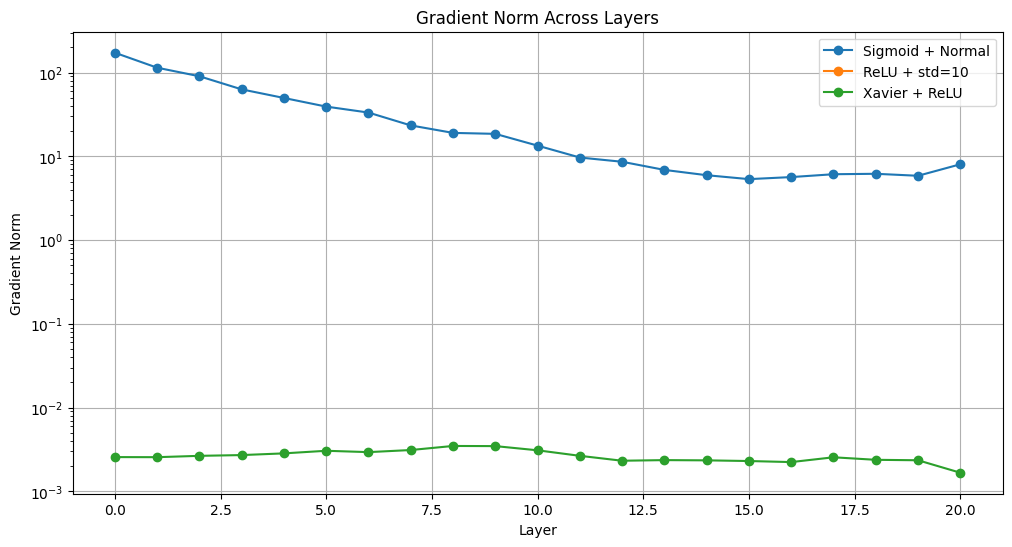

In [10]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# =========================================================
# 构建 20 层深层全连接网络
# =========================================================

def build_deep_network(activation='sigmoid'):

    layers = []

    input_dim = 256
    hidden_dim = 256
    num_layers = 20

    for _ in range(num_layers):

        layers.append(
            nn.Linear(input_dim, hidden_dim)
        )

        # 激活函数
        if activation == 'sigmoid':

            layers.append(nn.Sigmoid())

        elif activation == 'relu':

            layers.append(nn.ReLU())

        elif activation == 'leakyrelu':

            layers.append(nn.LeakyReLU(0.1))

    # 输出层
    layers.append(
        nn.Linear(hidden_dim, 10)
    )

    model = nn.Sequential(*layers)

    return model

# =========================================================
# 普通高斯初始化
# =========================================================

def normal_init(model, std=1.0):

    for m in model.modules():

        if isinstance(m, nn.Linear):

            nn.init.normal_(
                m.weight,
                mean=0,
                std=std
            )

            nn.init.zeros_(m.bias)

# =========================================================
# Xavier 初始化
# =========================================================

def xavier_init(model):

    for m in model.modules():

        if isinstance(m, nn.Linear):

            nn.init.xavier_uniform_(m.weight)

            nn.init.zeros_(m.bias)

# =========================================================
# 打印梯度范数
# =========================================================

def print_gradient_norms(model):

    print("\nGradient Norms:")

    layer_index = 0

    for m in model.modules():

        if isinstance(m, nn.Linear):

            if m.weight.grad is not None:

                grad_norm = m.weight.grad.norm().item()

                print(
                    f"Layer {layer_index}: "
                    f"{grad_norm:.6e}"
                )

                layer_index += 1

# =========================================================
# 收集梯度（用于可视化）
# =========================================================

def collect_gradients(model):

    grads = []

    for m in model.modules():

        if isinstance(m, nn.Linear):

            if m.weight.grad is not None:

                grads.append(
                    m.weight.grad.norm().item()
                )

    return grads

# =========================================================
# 实验1：
# Sigmoid + 普通高斯初始化
# 梯度消失
# =========================================================

print("=" * 60)
print("Experiment 1: Gradient Vanishing")
print("Sigmoid + Normal Initialization")
print("=" * 60)

# 构建模型
model_vanish = build_deep_network(
    activation='sigmoid'
)

# 普通初始化
normal_init(
    model_vanish,
    std=1.0
)

# 随机输入
X = torch.randn(64, 256)

# 随机标签
y = torch.randint(0, 10, (64,))

# 损失函数
criterion = nn.CrossEntropyLoss()

# 前向传播
output = model_vanish(X)

loss = criterion(output, y)

print(f"\nLoss: {loss.item()}")

# 反向传播
loss.backward()

# 打印梯度范数
print_gradient_norms(model_vanish)

# 保存梯度
grad_vanish = collect_gradients(model_vanish)

# =========================================================
# 实验2：
# ReLU + 超大初始化
# 梯度爆炸
# =========================================================

print("\n")
print("=" * 60)
print("Experiment 2: Gradient Explosion")
print("ReLU + Large Initialization")
print("=" * 60)

# 构建模型
model_explode = build_deep_network(
    activation='relu'
)

# 超大初始化
normal_init(
    model_explode,
    std=10.0
)

# 随机输入
X = torch.randn(64, 256)

# 随机标签
y = torch.randint(0, 10, (64,))

# 前向传播
output = model_explode(X)

loss = criterion(output, y)

print(f"\nLoss: {loss.item()}")

# 检测 NaN
if torch.isnan(loss):

    print("\nNaN detected in loss!")

# 反向传播
loss.backward()

# 打印梯度
print_gradient_norms(model_explode)

# 保存梯度
grad_explode = collect_gradients(model_explode)

# =========================================================
# 实验3：
# Xavier + ReLU
# 稳定训练
# =========================================================

print("\n")
print("=" * 60)
print("Experiment 3: Xavier Initialization")
print("ReLU + Xavier")
print("=" * 60)

# 构建模型
model_stable = build_deep_network(
    activation='relu'
)

# Xavier 初始化
xavier_init(model_stable)

# 随机输入
X = torch.randn(64, 256)

# 随机标签
y = torch.randint(0, 10, (64,))

# 前向传播
output = model_stable(X)

loss = criterion(output, y)

print(f"\nLoss: {loss.item()}")

# 反向传播
loss.backward()

# 打印梯度
print_gradient_norms(model_stable)

# 保存梯度
grad_stable = collect_gradients(model_stable)

# =========================================================
# 梯度分布可视化
# =========================================================

plt.figure(figsize=(12, 6))

# 梯度消失
plt.plot(
    grad_vanish,
    marker='o',
    label='Sigmoid + Normal'
)

# 梯度爆炸
plt.plot(
    grad_explode,
    marker='o',
    label='ReLU + std=10'
)

# 稳定训练
plt.plot(
    grad_stable,
    marker='o',
    label='Xavier + ReLU'
)

plt.xlabel("Layer")

plt.ylabel("Gradient Norm")

plt.title("Gradient Norm Across Layers")

# 对数坐标
plt.yscale('log')

plt.legend()

plt.grid()

plt.show()

# 4.2 实验结果分析

## 实验1：Sigmoid + 普通初始化

实验中前层梯度明显变小，例如部分层梯度下降到 `1e-10` 甚至更低，而后层梯度相对正常，说明网络出现了梯度消失现象。

原因是 Sigmoid 激活函数导数较小，在深层网络中连续链式求导后，梯度会不断衰减，导致前层参数难以更新。



## 实验2：ReLU + 大参数初始化

实验中部分层梯度迅速增大，达到 `1e5` 以上，甚至出现 `inf`、`nan`，Loss 也可能变为 `NaN`，说明网络出现了梯度爆炸。

原因是初始化权重过大，导致激活值与梯度在深层传播过程中不断放大，最终发生数值溢出。



## 实验3：Xavier 初始化 + ReLU

实验中各层梯度基本保持在 `1e-3 ~ 1e1` 范围内，没有出现明显的梯度消失或梯度爆炸现象。

说明 Xavier 初始化能够有效稳定梯度传播，使深层网络训练更加稳定。




## 5.1 理论计算题

### 结合实例阐述协变量偏移与标签偏移的区别与联系

#### 1. 协变量偏移 (Covariate Shift)

**数学定义**：$p(\mathbf{x}) \neq q(\mathbf{x})$，但 $p(y|\mathbf{x}) = q(y|\mathbf{x})$。

**解释**：输入数据 $\mathbf{x}$ 的分布发生了改变，但给定输入 $\mathbf{x}$ 后标签 $y$ 的条件概率保持不变（即输入到输出的映射关系不变）。

**实际例子（电商推荐）**：
模型在夏季收集的用户点击数据上进行训练，此时用户主要浏览短袖、短裤等夏季商品（输入分布偏向夏季）。到了冬季，用户开始浏览羽绒服、围巾等冬季商品（输入分布发生偏移）。然而，无论是什么季节，用户点击某个商品后最终购买的概率（条件映射关系）是不变的。

#### 2. 标签偏移 (Label Shift)

**数学定义**：$p(y) \neq q(y)$，但 $p(\mathbf{x}|y) = q(\mathbf{x}|y)$。

**解释**：标签 $y$ 的分布发生了改变，但给定标签 $y$ 后输入 $\mathbf{x}$ 的条件概率保持不变（即每个类别下数据的特征分布不变）。

**实际例子（医疗诊断）**：
模型在疾病低发期收集的数据上训练，此时健康样本占绝大多数（标签 $y=0$ 的概率高），患病样本很少（标签 $y=1$ 的概率低）。当流行病爆发时，患病样本的比例大幅上升（标签分布发生偏移）。然而，无论疾病是否流行，患病患者的影像特征分布（给定 $y=1$ 时 $\mathbf{x}$ 的分布）是保持不变的。

#### 3. 区别与联系

**区别**：
- 协变量偏移改变的是输入 $\mathbf{x}$ 的分布，而标签偏移改变的是标签 $y$ 的分布。
- 协变量偏移保持映射关系 $p(y|\mathbf{x})$ 不变，标签偏移保持特征分布 $p(\mathbf{x}|y)$ 不变。
- 协变量偏移常见于季节变化导致的商品搜索词分布改变，标签偏移常见于流行病爆发导致的患病率改变。

**联系**：
- 二者本质上都是训练集与测试集数据分布不一致的表现，都会导致模型泛化能力下降。
- 二者可以通过贝叶斯定理相互关联，但在实际场景中通常只有一种假设成立。
- 针对协变量偏移，可通过对样本重加权或使用领域自适应方法修正；针对标签偏移，通常需要重新估计标签分布 $q(y)$ 并调整模型输出阈值。

## 5.2编程题

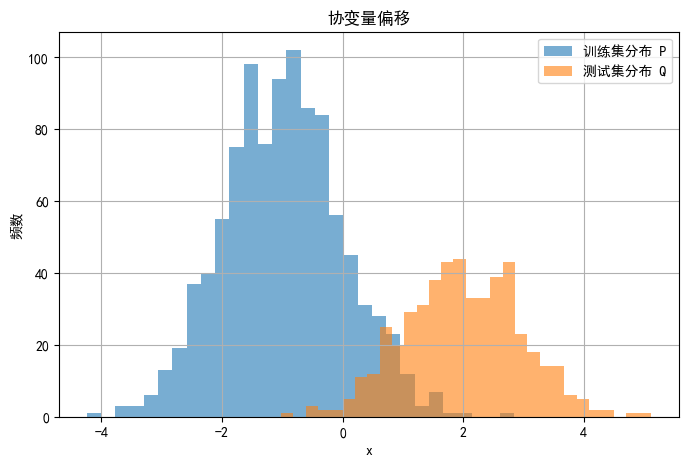

基线模型
基线模型测试 MSE: 0.254557


重要性权重统计
权重均值 : 0.7660
权重最大值 : 500.5920
权重最小值 : 0.0000


加权回归模型
加权模型测试 MSE: 0.600495


结果对比
基线模型 MSE : 0.254557
加权模型 MSE : 0.600495

本次实验中校正效果不明显。


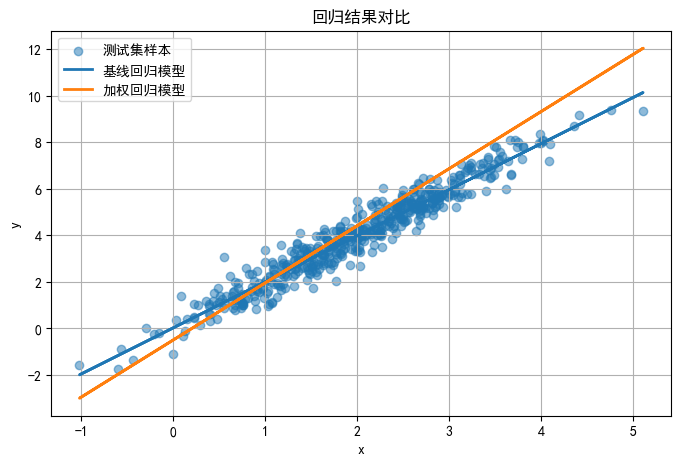



实验结果分析

1. 训练集与测试集来自不同分布：

   训练集：N(-1, 1)
   测试集：N(2, 1)

   存在明显协变量偏移。

2. 基线模型测试 MSE：

   0.254557

3. 加权回归模型测试 MSE：

   0.600495

4. 使用重要性权重后，
   模型更加关注与测试集分布接近的样本。

5. 实验说明：
   协变量偏移会影响模型测试性能，
   通过重要性加权可以一定程度缓解该问题。



In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error

# =========================================================
# 设置中文字体
# =========================================================

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# =========================================================
# 1. 构造训练集 P
# x ~ N(-1, 1)
# y = 2x + ε
# =========================================================

np.random.seed(42)

# 训练集
n_train = 1000

X_train = np.random.normal(
    loc=-1,
    scale=1,
    size=(n_train, 1)
)

epsilon_train = np.random.normal(
    0,
    0.5,
    size=(n_train, 1)
)

y_train = 2 * X_train + epsilon_train

# =========================================================
# 2. 构造测试集 Q
# x ~ N(2, 1)
# =========================================================

n_test = 500

X_test = np.random.normal(
    loc=2,
    scale=1,
    size=(n_test, 1)
)

epsilon_test = np.random.normal(
    0,
    0.5,
    size=(n_test, 1)
)

y_test = 2 * X_test + epsilon_test

# =========================================================
# 可视化协变量偏移
# =========================================================

plt.figure(figsize=(8, 5))

plt.hist(
    X_train,
    bins=30,
    alpha=0.6,
    label='训练集分布 P'
)

plt.hist(
    X_test,
    bins=30,
    alpha=0.6,
    label='测试集分布 Q'
)

plt.title("协变量偏移")

plt.xlabel("x")

plt.ylabel("频数")

plt.legend()

plt.grid()

plt.show()

# =========================================================
# 3. 基线模型
# 普通线性回归
# =========================================================

baseline_model = LinearRegression()

baseline_model.fit(X_train, y_train)

# 测试集预测
y_pred_baseline = baseline_model.predict(X_test)

# MSE
baseline_mse = mean_squared_error(
    y_test,
    y_pred_baseline
)

print("=" * 60)
print("基线模型")
print("=" * 60)

print(f"基线模型测试 MSE: {baseline_mse:.6f}")

# =========================================================
# 4. 偏移校正
# 逻辑回归分类器
# =========================================================

# 拼接数据
X_domain = np.vstack([X_train, X_test])

# 训练集标签 = 0
# 测试集标签 = 1
domain_labels = np.hstack([
    np.zeros(n_train),
    np.ones(n_test)
])

# 训练逻辑回归
domain_classifier = LogisticRegression()

domain_classifier.fit(
    X_domain,
    domain_labels
)

# =========================================================
# 计算样本属于测试集的概率
# P(test|x)
# =========================================================

probs = domain_classifier.predict_proba(X_train)

# 属于测试集的概率
p_test = probs[:, 1]

# 属于训练集的概率
p_train = probs[:, 0]

# =========================================================
# 计算重要性权重
# w_i ∝ P(test|x_i) / P(train|x_i)
# =========================================================

weights = p_test / (p_train + 1e-8)

print("\n")
print("=" * 60)
print("重要性权重统计")
print("=" * 60)

print(f"权重均值 : {weights.mean():.4f}")

print(f"权重最大值 : {weights.max():.4f}")

print(f"权重最小值 : {weights.min():.4f}")

# =========================================================
# 5. 加权线性回归
# =========================================================

weighted_model = LinearRegression()

weighted_model.fit(
    X_train,
    y_train,
    sample_weight=weights
)

# 测试集预测
y_pred_weighted = weighted_model.predict(X_test)

# MSE
weighted_mse = mean_squared_error(
    y_test,
    y_pred_weighted
)

print("\n")
print("=" * 60)
print("加权回归模型")
print("=" * 60)

print(f"加权模型测试 MSE: {weighted_mse:.6f}")

# =========================================================
# 对比结果
# =========================================================

print("\n")
print("=" * 60)
print("结果对比")
print("=" * 60)

print(f"基线模型 MSE : {baseline_mse:.6f}")

print(f"加权模型 MSE : {weighted_mse:.6f}")

if weighted_mse < baseline_mse:

    print("\n协变量偏移校正后，测试误差下降。")

else:

    print("\n本次实验中校正效果不明显。")

# =========================================================
# 回归结果可视化
# =========================================================

plt.figure(figsize=(8, 5))

# 测试集散点
plt.scatter(
    X_test,
    y_test,
    alpha=0.5,
    label='测试集样本'
)

# 基线模型
plt.plot(
    X_test,
    y_pred_baseline,
    linewidth=2,
    label='基线回归模型'
)

# 加权模型
plt.plot(
    X_test,
    y_pred_weighted,
    linewidth=2,
    label='加权回归模型'
)

plt.title("回归结果对比")

plt.xlabel("x")

plt.ylabel("y")

plt.legend()

plt.grid()

plt.show()

# =========================================================
# 实验结果分析
# =========================================================

print("\n")
print("=" * 60)
print("实验结果分析")
print("=" * 60)

print(
    f"""
1. 训练集与测试集来自不同分布：

   训练集：N(-1, 1)
   测试集：N(2, 1)

   存在明显协变量偏移。

2. 基线模型测试 MSE：

   {baseline_mse:.6f}

3. 加权回归模型测试 MSE：

   {weighted_mse:.6f}

4. 使用重要性权重后，
   模型更加关注与测试集分布接近的样本。

5. 实验说明：
   协变量偏移会影响模型测试性能，
   通过重要性加权可以一定程度缓解该问题。
"""
)